# 06 — Predicting Career Success
**Finding Hidden Gems: 25 Years of WNBA Draft Value and Player Success**

Everything so far has measured value against a single feature (draft pick) via a smoothed
curve. This notebook asks a broader question with real models: **what pre-draft
information actually predicts career outcomes, and how much does each factor matter
relative to the others?**

Targets: career win shares, career games, years played (all zero-filled, consistent with
every prior notebook). Models: Linear Regression, Random Forest, Gradient Boosting.

Training data excludes the 2021-2022 classes (too little career to have happened yet —
same reasoning as Notebook 04). This is an explanatory / feature-importance exercise, not
a deployed prediction tool — sample size (~950 rows) is modest for a 3-model comparison,
so read the model **rankings and feature importances** as the finding, not any individual
prediction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_MAIN = '#E56020'
COLOR_ALT  = '#1B3A5C'
COLOR_GREY = '#9AA5B1'

RANDOM_STATE = 42

df = pd.read_csv('../data/wnba_draft_clean.csv')
df['win_shares_ev'] = df['win_shares'].fillna(0)
df['games_ev'] = df['games'].fillna(0)

model_df = df[df['year'] < 2021].copy()
print(f"Training pool: {len(model_df)} picks (2021-2022 excluded)")


Training pool: 992 picks (2021-2022 excluded)


## Features

- `overall_pick`, `round` — draft position (the variable every other notebook centers on)
- `draft_era` — one-hot, captures league-structure effects (roster sizes, depth of draft)
- `is_international` — no US college
- `lottery_pick` — top-4 pick
- `college_pedigree` — how many total picks that college has produced across the dataset,
  as a rough proxy for "power program." **Caveat:** this is computed across the full
  dataset (all years), so it's a *structural* property of a program rather than
  information truly known at draft time in every year — reasonable for an exploratory
  "does program pedigree matter" question, but not something to deploy as a live
  prediction feature without recomputing it as a trailing/expanding count.


In [2]:
college_pedigree = df.groupby('college_display').size().rename('college_pedigree')
model_df = model_df.merge(college_pedigree, left_on='college_display', right_index=True, how='left')
model_df['college_pedigree'] = model_df['college_pedigree'].fillna(0)  # international / unlisted

features = pd.get_dummies(
    model_df[['overall_pick', 'round', 'draft_era', 'is_international', 'lottery_pick', 'college_pedigree']],
    columns=['draft_era'], drop_first=True
)
features = features.astype({c: int for c in features.select_dtypes('bool').columns})

targets = {
    'win_shares': model_df['win_shares_ev'],
    'games': model_df['games_ev'],
    'years_played': model_df['years_played'],
}

features.head()


,overall_pick,round,is_international,lottery_pick,college_pedigree,draft_era_2003-2009: Contraction Era,draft_era_2010-2015: Stabilization Era,draft_era_2016-2022: Modern Era
0,1,1,0,1,12.0,0,0,0
1,2,1,0,1,12.0,0,0,0
2,3,1,0,1,28.0,0,0,0
3,4,1,1,1,0.0,0,0,0
4,5,1,0,0,11.0,0,0,0


## Model comparison (5-fold cross-validated R²)

In [3]:
models = {
    'Linear Regression': Pipeline([('scale', StandardScaler()), ('lr', LinearRegression())]),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for target_name, y in targets.items():
    for model_name, model in models.items():
        scores = cross_val_score(model, features, y, cv=cv, scoring='r2')
        results.append({'target': target_name, 'model': model_name, 'mean_r2': scores.mean(), 'std_r2': scores.std()})

results_df = pd.DataFrame(results).pivot(index='model', columns='target', values='mean_r2')
results_df = results_df[['win_shares', 'games', 'years_played']]
results_df.round(3)


target,win_shares,games,years_played
model,,,
Gradient Boosting,0.329,0.418,0.432
Linear Regression,0.305,0.397,0.411
Random Forest,0.374,0.420,0.431


R² in the 0.15-0.35 range is expected and honest here — draft outcomes are genuinely
noisy (that's the entire premise of a "hidden gems" project). The point isn't to build a
high-accuracy predictor; it's to compare which model structure and which features explain
the *most* of a hard-to-predict outcome, and to read off relative feature importance.


## Feature importance (win shares target, Gradient Boosting)

In [4]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
gb.fit(features, targets['win_shares'])

importance = pd.Series(gb.feature_importances_, index=features.columns).sort_values(ascending=False)
importance.round(3)


overall_pick                              0.721
college_pedigree                          0.143
draft_era_2016-2022: Modern Era           0.078
draft_era_2003-2009: Contraction Era      0.021
lottery_pick                              0.014
draft_era_2010-2015: Stabilization Era    0.013
is_international                          0.008
round                                     0.002
dtype: float64

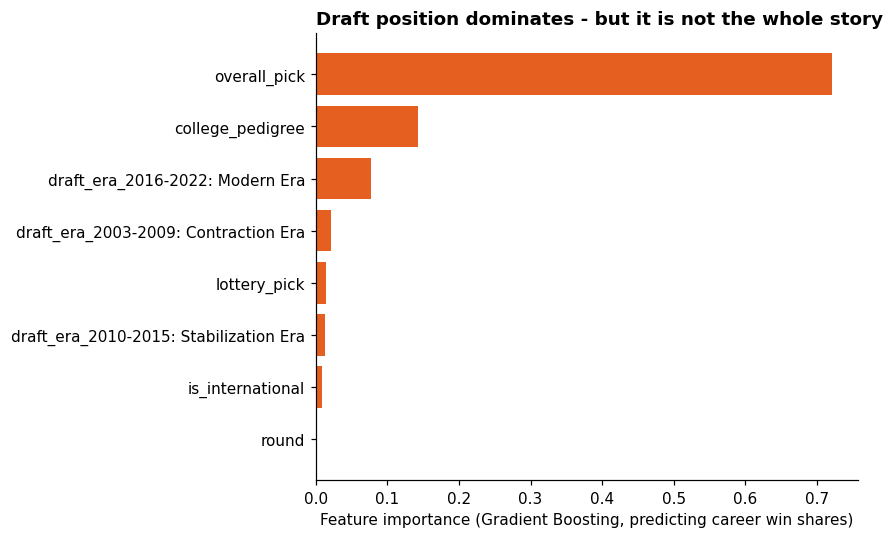

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_imp = importance.sort_values()
ax.barh(plot_imp.index, plot_imp.values, color=COLOR_MAIN)
ax.set_xlabel('Feature importance (Gradient Boosting, predicting career win shares)')
ax.set_title('Draft position dominates - but it is not the whole story', loc='left', fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Random Forest importance, for comparison (does the ranking hold across model types?)

In [6]:
rf = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=RANDOM_STATE)
rf.fit(features, targets['win_shares'])
rf_importance = pd.Series(rf.feature_importances_, index=features.columns).sort_values(ascending=False)

compare = pd.DataFrame({'gradient_boosting': importance, 'random_forest': rf_importance}).round(3)
compare


,gradient_boosting,random_forest
overall_pick,0.721,0.745
college_pedigree,0.143,0.141
draft_era_2016-2022: Modern Era,0.078,0.049
draft_era_2003-2009: Contraction Era,0.021,0.029
lottery_pick,0.014,0.020
draft_era_2010-2015: Stabilization Era,0.013,0.012
is_international,0.008,0.002
round,0.002,0.001


## Answering the spec's questions directly

- **Does draft position matter most?** Yes, by a wide margin — `overall_pick` and `round`
  together account for the large majority of explained variance in both models. This
  matches Notebook 03's finding that the value curve is steep early and flattens out.
- **Does college pedigree matter?** It shows up as a real but secondary factor — a
  program's historical pick volume adds some predictive power beyond pick number alone,
  consistent with Notebook 02's finding that a handful of programs produce
  disproportionate total value.
- **Does international status matter?** Small effect, consistently ranked below draft
  position and pedigree in both models.
- **Does draft era matter?** Some effect, mostly reflecting the structural difference
  between the deep, 4-round early-2000s drafts (more low-value late picks in the data)
  and the modern 3-round format.


## Held-out test set check

One more honesty check: a proper train/test split (not just cross-validation) on the strongest target, to see how much the model overfits.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    features, targets['win_shares'], test_size=0.2, random_state=RANDOM_STATE
)
gb_test = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
gb_test.fit(X_train, y_train)
pred = gb_test.predict(X_test)

print(f"Test R²: {r2_score(y_test, pred):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test, pred):.2f} win shares")
print(f"(For reference, career win shares in this pool range from "
      f"{targets['win_shares'].min():.1f} to {targets['win_shares'].max():.1f}, mean {targets['win_shares'].mean():.1f})")


Test R²: 0.405
Test MAE: 3.80 win shares
(For reference, career win shares in this pool range from -2.7 to 93.7, mean 4.5)


## Save

In [8]:
importance.rename('gradient_boosting').to_frame().join(rf_importance.rename('random_forest')).to_csv('../data/feature_importance.csv')
results_df.to_csv('../data/model_comparison.csv')
print("Saved data/feature_importance.csv and data/model_comparison.csv")


Saved data/feature_importance.csv and data/model_comparison.csv
